In [1]:
import os
import torch
import pandas as pd
import scanpy as sc
import warnings
from sigma.toolkit import set_seed
from sigma.toolkit import clustering
from sigma.data.preparation import build_spatial_triplet_inputs, prepare_rna_atac_features
import matplotlib.pyplot as plt
set_seed(2024)
warnings.filterwarnings('ignore')
device = torch.device('cuda:7' if torch.cuda.is_available() else 'cpu')
file_fold = '../SIGMA_data/Mouse_Brain_E15_S1/'  #please replace 'file_fold' with the download path
adata_omics1 = sc.read_h5ad(file_fold + 'adata_RNA.h5ad')
adata_omics2 = sc.read_h5ad(file_fold + 'adata_ATAC.h5ad')
adata_omics1.var_names_make_unique()
adata_omics2.var_names_make_unique()
adata_omics1.obs["anno"]=pd.read_csv(file_fold+"anno.csv",index_col=0)["cluster"]
adata_omics1,adata_omics2


/opt/miniconda/envs/smart_new/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(AnnData object with n_obs × n_vars = 1949 × 32285
     obs: 'gex_barcode', 'atac_barcode', 'is_cell', 'excluded_reason', 'gex_raw_reads', 'gex_mapped_reads', 'gex_conf_intergenic_reads', 'gex_conf_exonic_reads', 'gex_conf_intronic_reads', 'gex_conf_exonic_unique_reads', 'gex_conf_exonic_antisense_reads', 'gex_conf_exonic_dup_reads', 'gex_exonic_umis', 'gex_conf_intronic_unique_reads', 'gex_conf_intronic_antisense_reads', 'gex_conf_intronic_dup_reads', 'gex_intronic_umis', 'gex_conf_txomic_unique_reads', 'gex_umis_count', 'gex_genes_count', 'atac_raw_reads', 'atac_unmapped_reads', 'atac_lowmapq', 'atac_dup_reads', 'atac_chimeric_reads', 'atac_mitochondrial_reads', 'atac_fragments', 'atac_TSS_fragments', 'atac_peak_region_fragments', 'atac_peak_region_cutsites', 'anno'
     var: 'gene_ids', 'feature_types', 'genome'
     obsm: 'spatial',
 AnnData object with n_obs × n_vars = 1949 × 141420
     obs: 'gex_barcode', 'atac_barcode', 'is_cell', 'excluded_reason', 'gex_raw_reads', 'gex_mapped

In [2]:
adata_omics1, adata_omics2, adata_list = prepare_rna_atac_features(
    adata_rna=adata_omics1,
    adata_atac=adata_omics2,
    min_cells=10,
    n_top_genes=3000,
    rna_n_comps=30,
    atac_n_comps=60,
    align_atac=True,
    atac_scale_factor=1e4,
    atac_counts_per_cell_after=1e4,
)
x, edges, triplet_samples_list = build_spatial_triplet_inputs(
    adata_list=adata_list,
    rna_adata=adata_omics1,
    device=device,
    n_neighbors=4,
    edge_ratio=0.005,
    triplet_neighbors=3,
    farthest_ratio=0.6,
)


The graph contains 7796 edges, 1949 cells.
4.0000 neighbors per cell on average.
The graph contains 7796 edges, 1949 cells.
4.0000 neighbors per cell on average.
Original edges: 7796, planned new edges: 38
Actual directed new edges after deduplication: 70
  Final modality edge count: 7866
  Final modality edge count: 7866
Distances calculation completed!
The data using feature 'feat' contains 1470 mnn_anchors
Distances calculation completed!
The data using feature 'feat' contains 1370 mnn_anchors


In [3]:
from sigma.training import fit_sigma_embedding
model = fit_sigma_embedding(
    adata=adata_omics1,
    features=x,
    edges=edges,
    triplet_samples_list=triplet_samples_list,
    weights=[1, 1, 1, 1],
    emb_dim=64,
    n_epochs=450,
    lr=1e-4,
    weight_decay=8e-6,
    device=device,
    window_size=10,
    slope=1e-4,
    seed=2024,
    move_model_to=device,
)
from sigma.reporting import cluster_and_score_ari
tool = 'mclust'  # mclust, leiden, and louvain
ari = cluster_and_score_ari(
    adata_omics1,
    label_key='anno',
    cluster_key='SIGMA',
    embedding_key='SIGMA',
    n_clusters=11,
    method=tool,
    use_pca=True,
)


100%|██████████| 450/450 [00:40<00:00, 11.03it/s]
R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.2
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%
0.6444599527841401


In [4]:
from sigma.reporting import report_clustering_metrics
tool = 'mclust'
scores = report_clustering_metrics(
    adata_omics1,
    label_key='anno',
    cluster_key='SIGMA',
    embedding_key='SIGMA',
    n_clusters=11,
    method=tool,
    use_pca=True,
)
ari = scores["ARI"]


fitting ...
  |======================================================================| 100%
ARI: 0.6445
NMI: 0.6559
AMI: 0.6510
Homo: 0.6598
V-measure: 0.6559
FMI: 0.7028
MI: 1.3549


fitting ...
  |======================================================================| 100%
10
Cluster color map used for SIGMA spatial panel:
  1: #ff7f0e
  2: #d0021b
  3: #17becf
  4: #e377c2
  5: #7ed321
  6: #2ca02c
  7: #1f77b4
  8: #9467bd
  9: #d62728
  10: #a7a8aa
  11: #4a90e2
Saved E15 plots to: ./Mouse_Brain_E15_SIGMA_plots


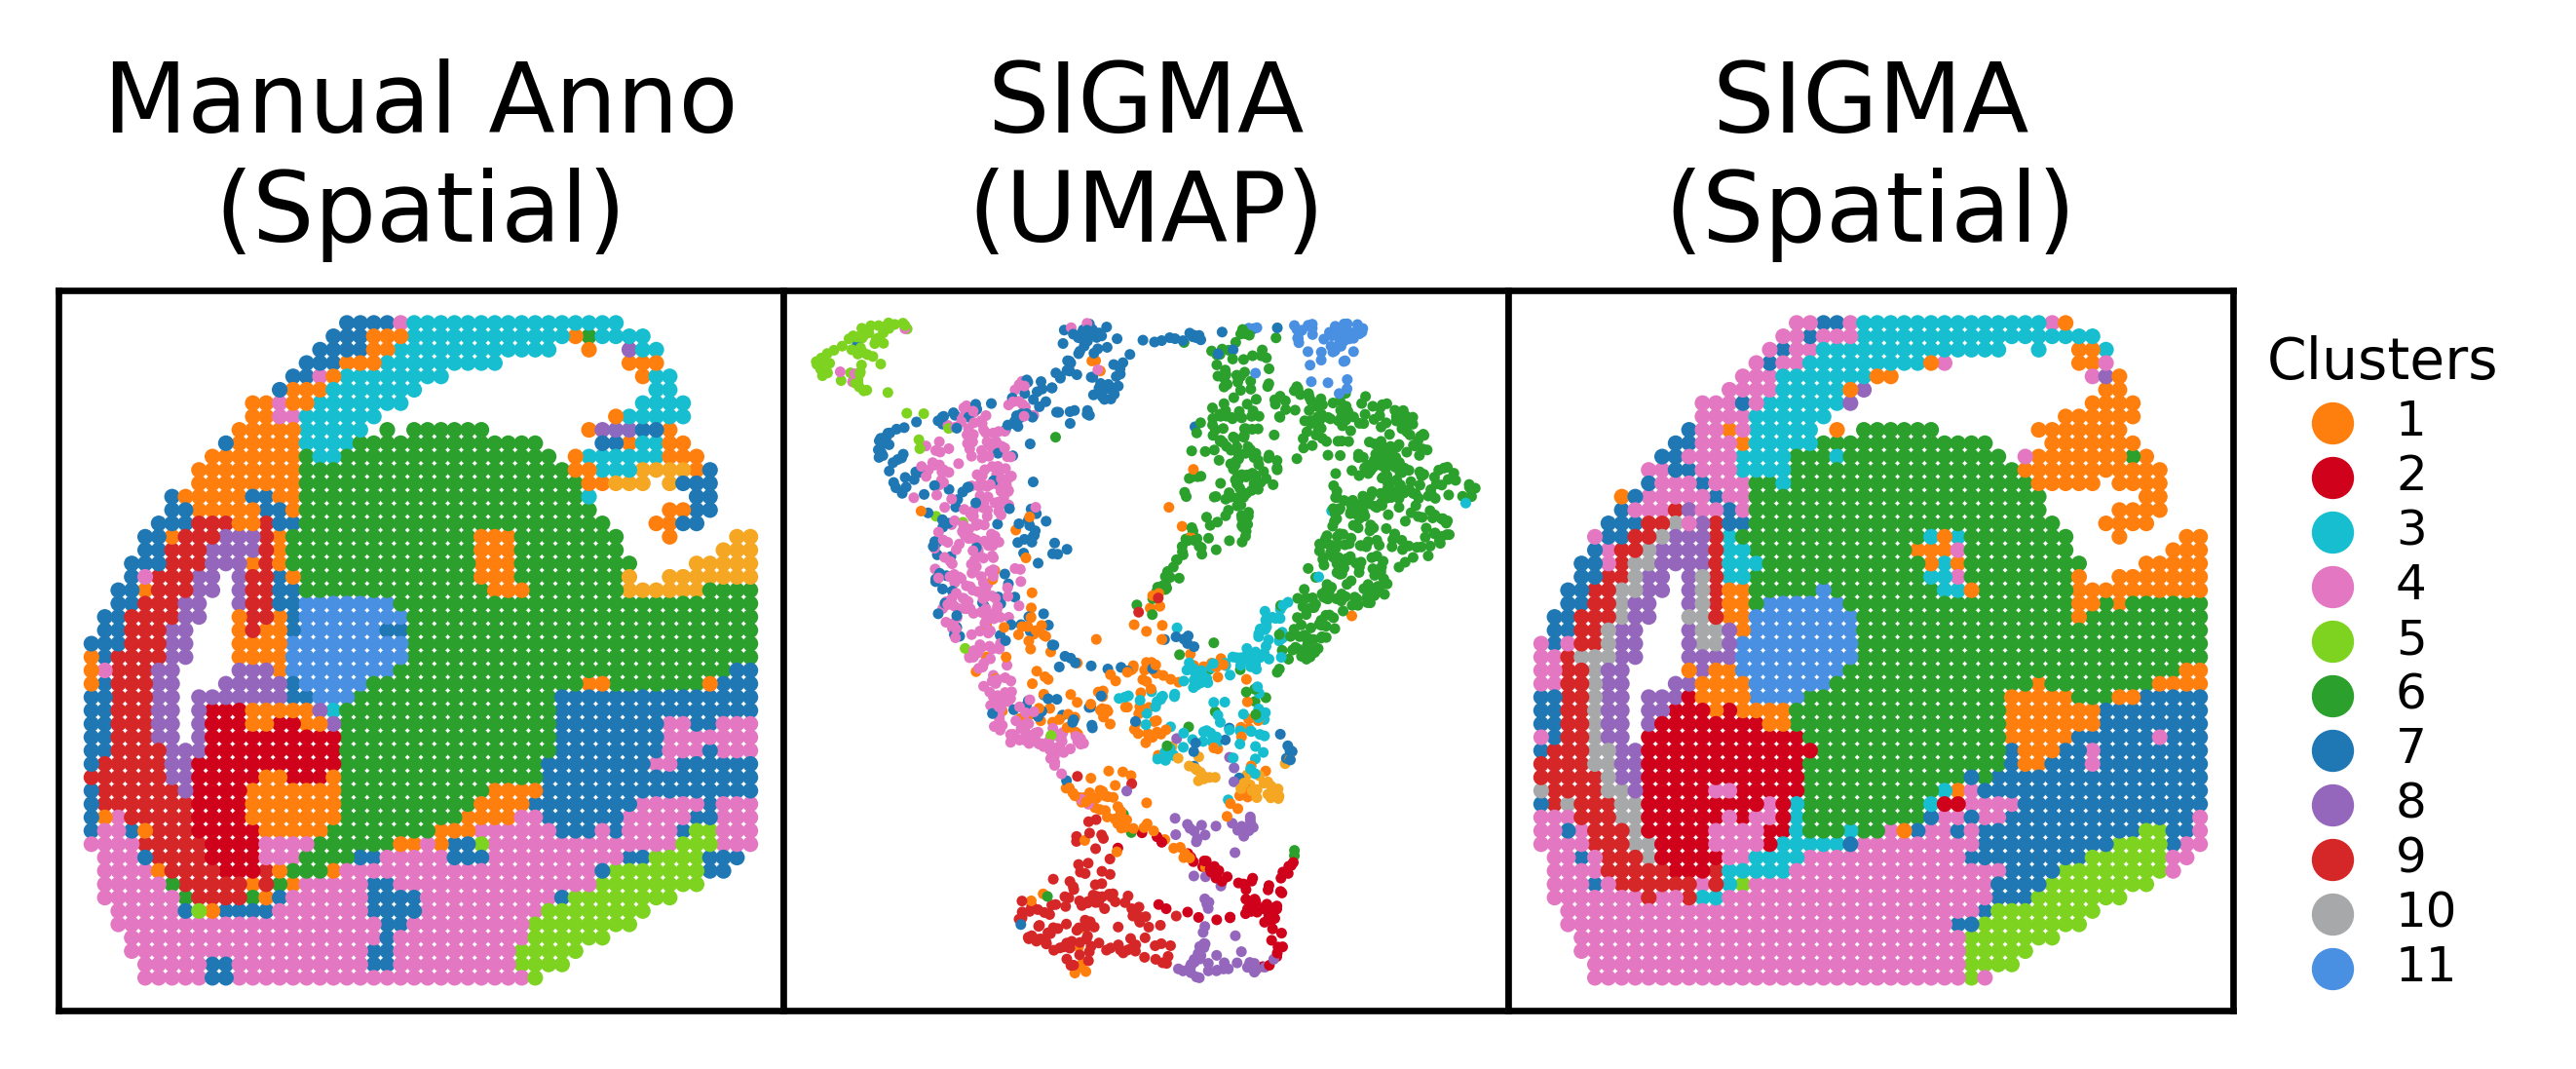

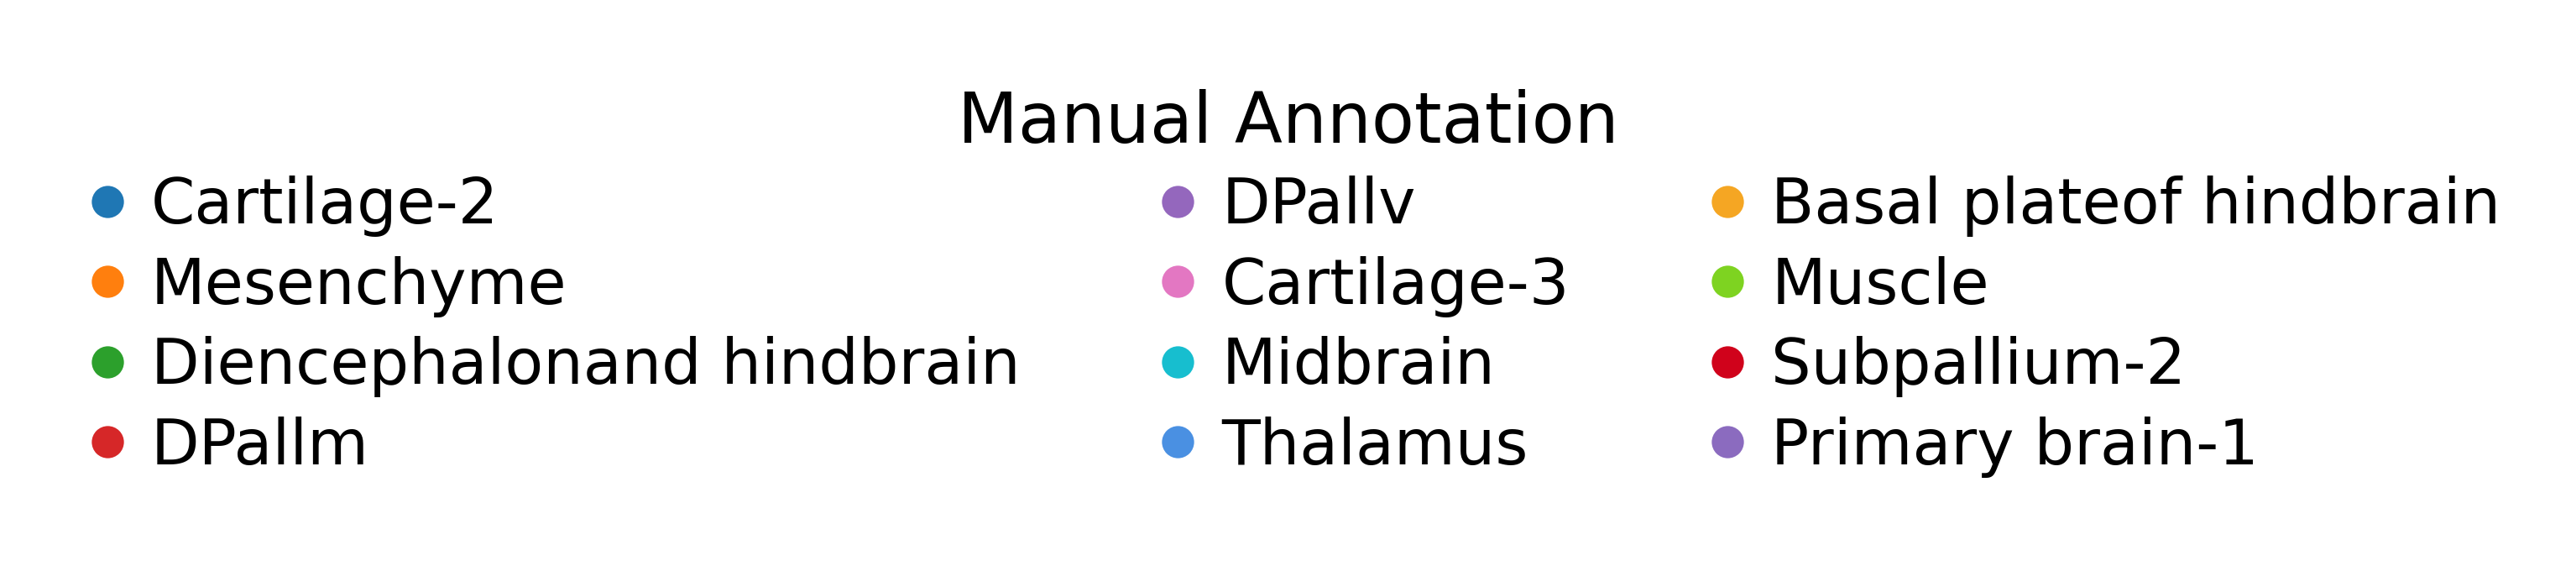

In [5]:
from sigma.toolkit import getcolordict
# ===== Cell 2: explicitly assign each E15 cluster color, then plot =====
plot_out_dir = os.path.join(".", "Mouse_Brain_E15_SIGMA_plots")
os.makedirs(plot_out_dir, exist_ok=True)
embedding_key = "SIGMA"
cluster_key = "SIGMA_11"
anno_key = "anno"
if embedding_key not in adata_omics1.obsm:
    raise KeyError(f"adata_omics1.obsm['{embedding_key}'] is missing. Run the model training cell first.")
if cluster_key not in adata_omics1.obs:
    clustering(
        adata_omics1,
        key=embedding_key,
        add_key=cluster_key,
        n_clusters=11,
        method="mclust",
        use_pca=True
    )
adata_omics1.obs[anno_key] = adata_omics1.obs[anno_key].astype(str)
adata_omics1.obs[cluster_key] = adata_omics1.obs[cluster_key].astype(str)
# =========================
# Manual annotation colors (KEEP FIXED)
# =========================
anno_palette = {
    "Cartilage-2": "#1f77b4",
    "Mesenchyme": "#ff7f0e",
    "Diencephalonand hindbrain": "#2ca02c",
    "DPallm": "#d62728",
    "DPallv": "#9467bd",
    "Subpallium-1": "#8c564b",
    "Cartilage-3": "#e377c2",
    "Cartilage-1": "#7f7f7f",
    "Cartilage-4": "#bcbd22",
    "Midbrain": "#17becf",
    "Thalamus": "#4a90e2",
    "Basal plateof hindbrain": "#f5a623",
    "Muscle": "#7ed321",
    "Subpallium-2": "#d0021b",
    "Primary brain-1": "#8b6bbf",
    "Primary brain-2": "#a7a8aa",
}
cluster_color_map = getcolordict(
    adata_omics1,
    my_cluster=cluster_key,
    true_cluster=anno_key,
    colordict=anno_palette
)
# =========================
# cluster order stability
# =========================
cluster_order = sorted(
    adata_omics1.obs[cluster_key].dropna().unique().astype(str),
    key=lambda x: int(x) if x.isdigit() else x,
)
missing_cluster_colors = [x for x in cluster_order if x not in cluster_color_map]
if missing_cluster_colors:
    raise ValueError(f"cluster_color_map is missing colors for clusters: {missing_cluster_colors}")
adata_omics1.obs[cluster_key] = pd.Categorical(
    adata_omics1.obs[cluster_key].astype(str),
    categories=cluster_order,
    ordered=True,
)
# =========================
# fill anno fallback (same as before)
# =========================
fallback_colors = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b",
    "#e377c2", "#7f7f7f", "#bcbd22", "#17becf", "#4a90e2", "#f5a623",
    "#7ed321", "#d0021b", "#8b6bbf", "#a7a8aa",
]
for i, anno_name in enumerate(pd.Index(adata_omics1.obs[anno_key]).drop_duplicates()):
    anno_palette.setdefault(str(anno_name), fallback_colors[i % len(fallback_colors)])
# clear scanpy cached colors
adata_omics1.uns.pop(f"{anno_key}_colors", None)
adata_omics1.uns.pop(f"{cluster_key}_colors", None)
# =========================
# recompute UMAP
# =========================
adata_omics1.obsm["X_SIGMA"] = adata_omics1.obsm[embedding_key]
sc.pp.neighbors(adata_omics1, use_rep="X_SIGMA", n_neighbors=10)
sc.tl.umap(adata_omics1, random_state=2024)
# =========================
# plotting
# =========================
plt.rcParams["legend.fontsize"] = 6
plt.rcParams["legend.title_fontsize"] = 7
plt.rcParams["legend.labelspacing"] = 0.1
plt.rcParams["legend.handlelength"] = 1
plt.rcParams["legend.markerscale"] = 0.7
fig, ax_list = plt.subplots(1, 3, figsize=(4.8, 1.6), dpi=600)
plt.subplots_adjust(wspace=0)
sc.pl.embedding(
    adata_omics1,
    basis="spatial",
    color=anno_key,
    ax=ax_list[0],
    title="Manual Anno\n(Spatial)",
    s=15,
    palette=anno_palette,
    show=False,
)
sc.pl.umap(
    adata_omics1,
    color=anno_key,
    ax=ax_list[1],
    title="SIGMA\n(UMAP)",
    s=7,
    palette=anno_palette,
    legend_fontsize=7,
    show=False,
)
sc.pl.embedding(
    adata_omics1,
    basis="spatial",
    color=cluster_key,
    ax=ax_list[2],
    title="SIGMA\n(Spatial)",
    s=15,
    palette=cluster_color_map,
    show=False,
)
for ax in ax_list:
    ax.set_xlabel("")
    ax.set_ylabel("")
if ax_list[0].get_legend() is not None:
    ax_list[0].get_legend().remove()
if ax_list[1].get_legend() is not None:
    ax_list[1].get_legend().remove()
if ax_list[2].get_legend() is not None:
    ax_list[2].legend(
        loc=(1.02, 0),
        labelspacing=0.16,
        frameon=False,
        ncol=1,
        title="Clusters"
    )
fig.savefig(os.path.join(plot_out_dir, "E15_cluster_umap_source_colors.jpg"), bbox_inches="tight", transparent=True)
fig.savefig(os.path.join(plot_out_dir, "E15_cluster_umap_source_colors.png"), bbox_inches="tight", transparent=True)
# =========================
# legend
# =========================
circle_handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=color, markersize=8, label=region)
    for region, color in anno_palette.items()
    if region in set(adata_omics1.obs[anno_key].astype(str))
]
fig_legend, ax_legend = plt.subplots(figsize=(4.8, 1.2), dpi=600)
ax_legend.axis("off")
ax_legend.legend(
    title="Manual Annotation",
    handles=circle_handles,
    loc="center",
    frameon=False,
    ncol=3,
    labelspacing=0.3,
    handletextpad=0.2,
    fontsize=9,
    title_fontsize=10,
)
fig_legend.savefig(os.path.join(plot_out_dir, "E15_manual_annotation_legend_source_colors.jpg"), bbox_inches="tight", transparent=True)
fig_legend.savefig(os.path.join(plot_out_dir, "E15_manual_annotation_legend_source_colors.png"), bbox_inches="tight", transparent=True)
print("Cluster color map used for SIGMA spatial panel:")
for cluster_id in cluster_order:
    print(f"  {cluster_id}: {cluster_color_map[cluster_id]}")
print(f"Saved E15 plots to: {plot_out_dir}")
plt.show()
